In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('train.csv')
print(df.shape)
print(df.head())
print(df.isnull().sum())

(9800, 18)
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID 

In [3]:
# Fix date columns
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month_Name'] = df['Order Date'].dt.strftime('%b')

print("Years in data:", df['Year'].unique())
print("Categories:", df['Category'].unique())
print("Segments:", df['Segment'].unique())
print("Regions:", df['Region'].unique())
print("\nTotal Sales: $", round(df['Sales'].sum(), 2))

Years in data: [2017 2016 2015 2018]
Categories: <StringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str
Segments: <StringArray>
['Consumer', 'Corporate', 'Home Office']
Length: 3, dtype: str
Regions: <StringArray>
['South', 'West', 'Central', 'East']
Length: 4, dtype: str

Total Sales: $ 2261536.78


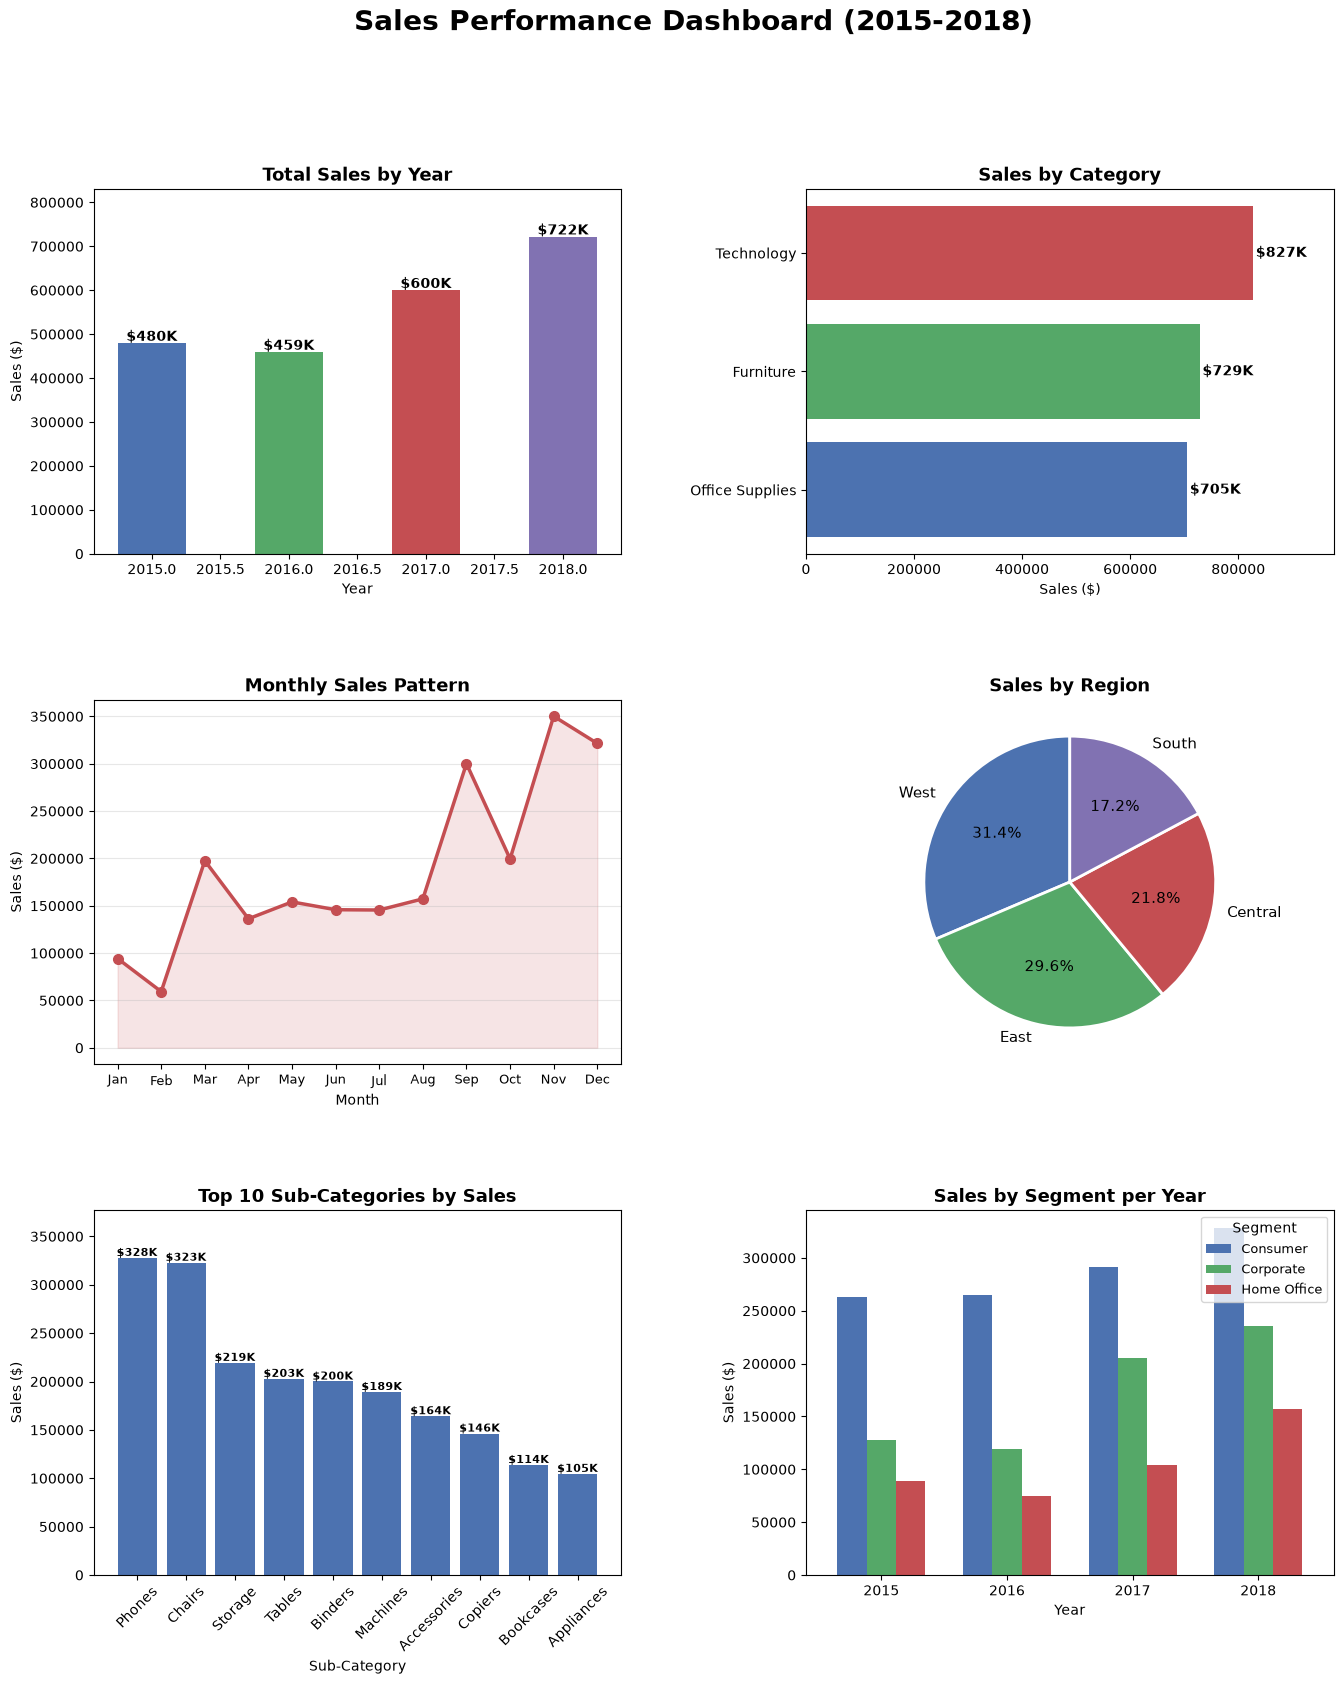


✅ Dashboard saved as sales_dashboard.png


In [4]:
# ============================================================
# SALES DASHBOARD - Complete Analysis
# ============================================================

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Sales Performance Dashboard (2015-2018)', 
             fontsize=20, fontweight='bold', y=0.98)
plt.subplots_adjust(hspace=0.4, wspace=0.35)

# ── Chart 1: Yearly Sales Trend ──────────────────────────────
yearly = df.groupby('Year')['Sales'].sum().reset_index()
axes[0,0].bar(yearly['Year'], yearly['Sales'], color=['#4C72B0','#55A868','#C44E52','#8172B2'], width=0.5)
axes[0,0].set_title('Total Sales by Year', fontweight='bold', fontsize=13)
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Sales ($)')
for i, row in yearly.iterrows():
    axes[0,0].text(row['Year'], row['Sales']+5000, f"${row['Sales']/1000:.0f}K", 
                   ha='center', fontsize=10, fontweight='bold')
axes[0,0].set_ylim(0, yearly['Sales'].max() * 1.15)

# ── Chart 2: Sales by Category ───────────────────────────────
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=True)
colors = ['#4C72B0','#55A868','#C44E52']
axes[0,1].barh(cat_sales.index, cat_sales.values, color=colors)
axes[0,1].set_title('Sales by Category', fontweight='bold', fontsize=13)
axes[0,1].set_xlabel('Sales ($)')
for i, (val, name) in enumerate(zip(cat_sales.values, cat_sales.index)):
    axes[0,1].text(val + 5000, i, f'${val/1000:.0f}K', va='center', fontsize=10, fontweight='bold')
axes[0,1].set_xlim(0, cat_sales.max() * 1.18)

# ── Chart 3: Monthly Sales Trend (all years combined) ────────
monthly = df.groupby('Month')['Sales'].sum().reset_index()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[1,0].plot(monthly['Month'], monthly['Sales'], marker='o', 
               color='#C44E52', linewidth=2.5, markersize=7)
axes[1,0].fill_between(monthly['Month'], monthly['Sales'], alpha=0.15, color='#C44E52')
axes[1,0].set_title('Monthly Sales Pattern', fontweight='bold', fontsize=13)
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('Sales ($)')
axes[1,0].set_xticks(range(1,13))
axes[1,0].set_xticklabels(month_labels, fontsize=9)
axes[1,0].grid(axis='y', alpha=0.3)

# ── Chart 4: Sales by Region ─────────────────────────────────
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
wedge_props = {'linewidth': 2, 'edgecolor': 'white'}
axes[1,1].pie(region_sales.values, labels=region_sales.index, autopct='%1.1f%%',
              colors=['#4C72B0','#55A868','#C44E52','#8172B2'],
              wedgeprops=wedge_props, startangle=90, textprops={'fontsize': 11})
axes[1,1].set_title('Sales by Region', fontweight='bold', fontsize=13)

# ── Chart 5: Top 10 Sub-Categories ───────────────────────────
subcat = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)
axes[2,0].bar(subcat.index, subcat.values, color='#4C72B0')
axes[2,0].set_title('Top 10 Sub-Categories by Sales', fontweight='bold', fontsize=13)
axes[2,0].set_xlabel('Sub-Category')
axes[2,0].set_ylabel('Sales ($)')
axes[2,0].tick_params(axis='x', rotation=45)
for i, val in enumerate(subcat.values):
    axes[2,0].text(i, val + 2000, f'${val/1000:.0f}K', ha='center', fontsize=8, fontweight='bold')
axes[2,0].set_ylim(0, subcat.max() * 1.15)

# ── Chart 6: Sales by Customer Segment ───────────────────────
seg_yearly = df.groupby(['Year','Segment'])['Sales'].sum().unstack()
seg_yearly.plot(kind='bar', ax=axes[2,1], color=['#4C72B0','#55A868','#C44E52'], width=0.7)
axes[2,1].set_title('Sales by Segment per Year', fontweight='bold', fontsize=13)
axes[2,1].set_xlabel('Year')
axes[2,1].set_ylabel('Sales ($)')
axes[2,1].tick_params(axis='x', rotation=0)
axes[2,1].legend(title='Segment', fontsize=9)

plt.savefig('sales_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Dashboard saved as sales_dashboard.png")

In [5]:
print("=" * 55)
print("        KEY BUSINESS INSIGHTS")
print("=" * 55)

# Insight 1: Best year
best_year = yearly.loc[yearly['Sales'].idxmax()]
print(f"\n📈 Best Year: {int(best_year['Year'])} — ${best_year['Sales']:,.0f}")

# Insight 2: YoY growth
sales_2015 = yearly[yearly['Year']==2015]['Sales'].values[0]
sales_2018 = yearly[yearly['Year']==2018]['Sales'].values[0]
growth = ((sales_2018 - sales_2015) / sales_2015) * 100
print(f"📊 Sales Growth 2015→2018: {growth:.1f}%")

# Insight 3: Top category
top_cat = cat_sales.idxmax()
top_cat_pct = (cat_sales.max() / cat_sales.sum()) * 100
print(f"🏆 Top Category: {top_cat} ({top_cat_pct:.1f}% of sales)")

# Insight 4: Top region
top_region = region_sales.idxmax()
top_region_pct = (region_sales.max() / region_sales.sum()) * 100
print(f"🌍 Top Region: {top_region} ({top_region_pct:.1f}% of sales)")

# Insight 5: Best month
best_month_num = monthly.loc[monthly['Sales'].idxmax(), 'Month']
best_month_name = month_labels[best_month_num - 1]
best_month_sales = monthly['Sales'].max()
print(f"📅 Peak Month: {best_month_name} (${best_month_sales:,.0f} total)")

# Insight 6: Top sub-category
print(f"🥇 Top Sub-Category: {subcat.index[0]} (${subcat.values[0]:,.0f})")

# Insight 7: Consumer vs others
consumer_pct = (df[df['Segment']=='Consumer']['Sales'].sum() / df['Sales'].sum()) * 100
print(f"👥 Consumer Segment: {consumer_pct:.1f}% of total revenue")

        KEY BUSINESS INSIGHTS

📈 Best Year: 2018 — $722,052
📊 Sales Growth 2015→2018: 50.5%
🏆 Top Category: Technology (36.6% of sales)
🌍 Top Region: West (31.4% of sales)
📅 Peak Month: Nov ($350,162 total)
🥇 Top Sub-Category: Phones ($327,782)
👥 Consumer Segment: 50.8% of total revenue
